# Jupyter notebook to interact with data

Follow setup instructions in README.md and if in vscode, use shortcut Ctrl+Shift+P and type Python: Select Interpreter, then you might have to type full path (Enter interpreter path, Find..., /bigtemp/computing_id/MicroNetCNN/.venv/bin/python3), then in top right you should be able to select kernel as that venv

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.layers import StringLookup
import pandas as pd
import os
from pathlib import Path
from collections import Counter
import json

In [36]:
def summarize_micronet():
    with open('micronet_annotations.json', 'r') as f:
        annotations = json.load(f)
    
    existing_files = set(os.listdir('micronet_images'))
    
    class_counts = Counter()
    missing_files = 0
    
    for uuid, data in annotations.items():
        file_name = f"{uuid}.jpg" 
        
        if file_name in existing_files:
            label = data.get('species_guess', 'unknown') 
            class_counts[label] += 1
        else:
            missing_files += 1

    img_path = Path('micronet_images')
    files = [f for f in img_path.rglob('*') if f.is_file()]
    total_bytes = sum(f.stat().st_size for f in files)
    total_gb = total_bytes / (1024**3)
    
    print("--- Micronet Dataset Summary ---")
    print(f"Total Annotations: {len(annotations)}")
    print(f"Actual Images on Disk: {len(existing_files)}")
    print(f"Failed Downloads: {missing_files}")
    print(f"Number of classes: {len(class_counts)}")
    print(f"Total Disk Usage:      {total_gb:.2f} GB")
    
    print("\n--- Class Distribution ---")
    
    for label, count in class_counts.most_common():
        print(f"{label} {count}")

summarize_micronet()

--- Micronet Dataset Summary ---
Total Annotations: 10059
Actual Images on Disk: 10039
Failed Downloads: 20
Number of classes: 2603
Total Disk Usage:      2.71 GB

--- Class Distribution ---
Pediastrum duplex 252
Melosira varians 185
Stauridium tetras 173
Pseudopediastrum boryanum 142
Epithemia gibba 110
Urocentrum turbo 97
Terpsinoe musica 90
Stentor roeselii 84
Lepocinclis acus 82
Surirella librile 79
Anthophysa vegetans 75
Tetradesmus lagerheimii 72
Micrasterias truncata 71
Microcystis aeruginosa 70
Stentor coeruleus 65
Monactinus simplex 65
Vorticella campanula 65
Bacillaria paxillifera 54
Woronichinia naegeliana 50
Netrium digitus 49
Asterionella formosa 49
Closterium acerosum 49
Green Hydra 48
Micrasterias furcata 47
Desmodesmus communis 46
Closterium moniliferum 45
Tetradesmus obliquus 45
Lepocinclis fusca 44
Euglena ehrenbergii 41
Fragilaria crotonensis 40
Ceratium hirundinella 40
Achromatium oxaliferum 40
Pandorina morum 38
carpenter's rule diatom 36
Bambusina borreri 36
Goniu

In [37]:
with open('micronet_annotations.json', 'r') as f:
    annotations = json.load(f)

unique_labels = sorted(list(set(v['species_guess'] for v in annotations.values())))
label_to_index = {label: i for i, label in enumerate(unique_labels)}

def create_split_df(json_path):
    with open(json_path, 'r') as f:
        uuids = json.load(f)
        
    data = []
    for uid in uuids:
        img_path = os.path.join(f'micronet_images/{uid}.jpg')
        if os.path.exists(img_path) and uid in annotations:
            data.append({
                'path': f"micronet_images/{uid}.jpg",
                'label': annotations[uid]['species_guess']
            })
    return pd.DataFrame(data)

train_df = create_split_df('train.json')
test_df = create_split_df('test.json')
val_df = create_split_df('val.json')

In [43]:
IMG_SIZE = 150
BATCH_SIZE = 32

all_species = sorted(list(set(v['species_guess'] for v in annotations.values())))
label_encoder = StringLookup(vocabulary=all_species, mask_token=None)

def parse_function(filename, label):
    image_string = tf.io.read_file(filename)
    image = tf.image.decode_image(image_string, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    
    image = tf.image.convert_image_dtype(image, tf.float32) 
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    
    label_idx = label_encoder(label)
    return image, label_idx

def create_dataset(df, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((df['path'].values, df['label'].values))
    if shuffle:
        dataset = dataset.shuffle(len(df))
    
    dataset = dataset.map(parse_function, num_parallel_calls=tf.data.AUTOTUNE)
    return dataset.batch(32).prefetch(tf.data.AUTOTUNE)

train_ds = create_dataset(train_df, shuffle=True)
test_ds = create_dataset(test_df)
val_ds = create_dataset(val_df)

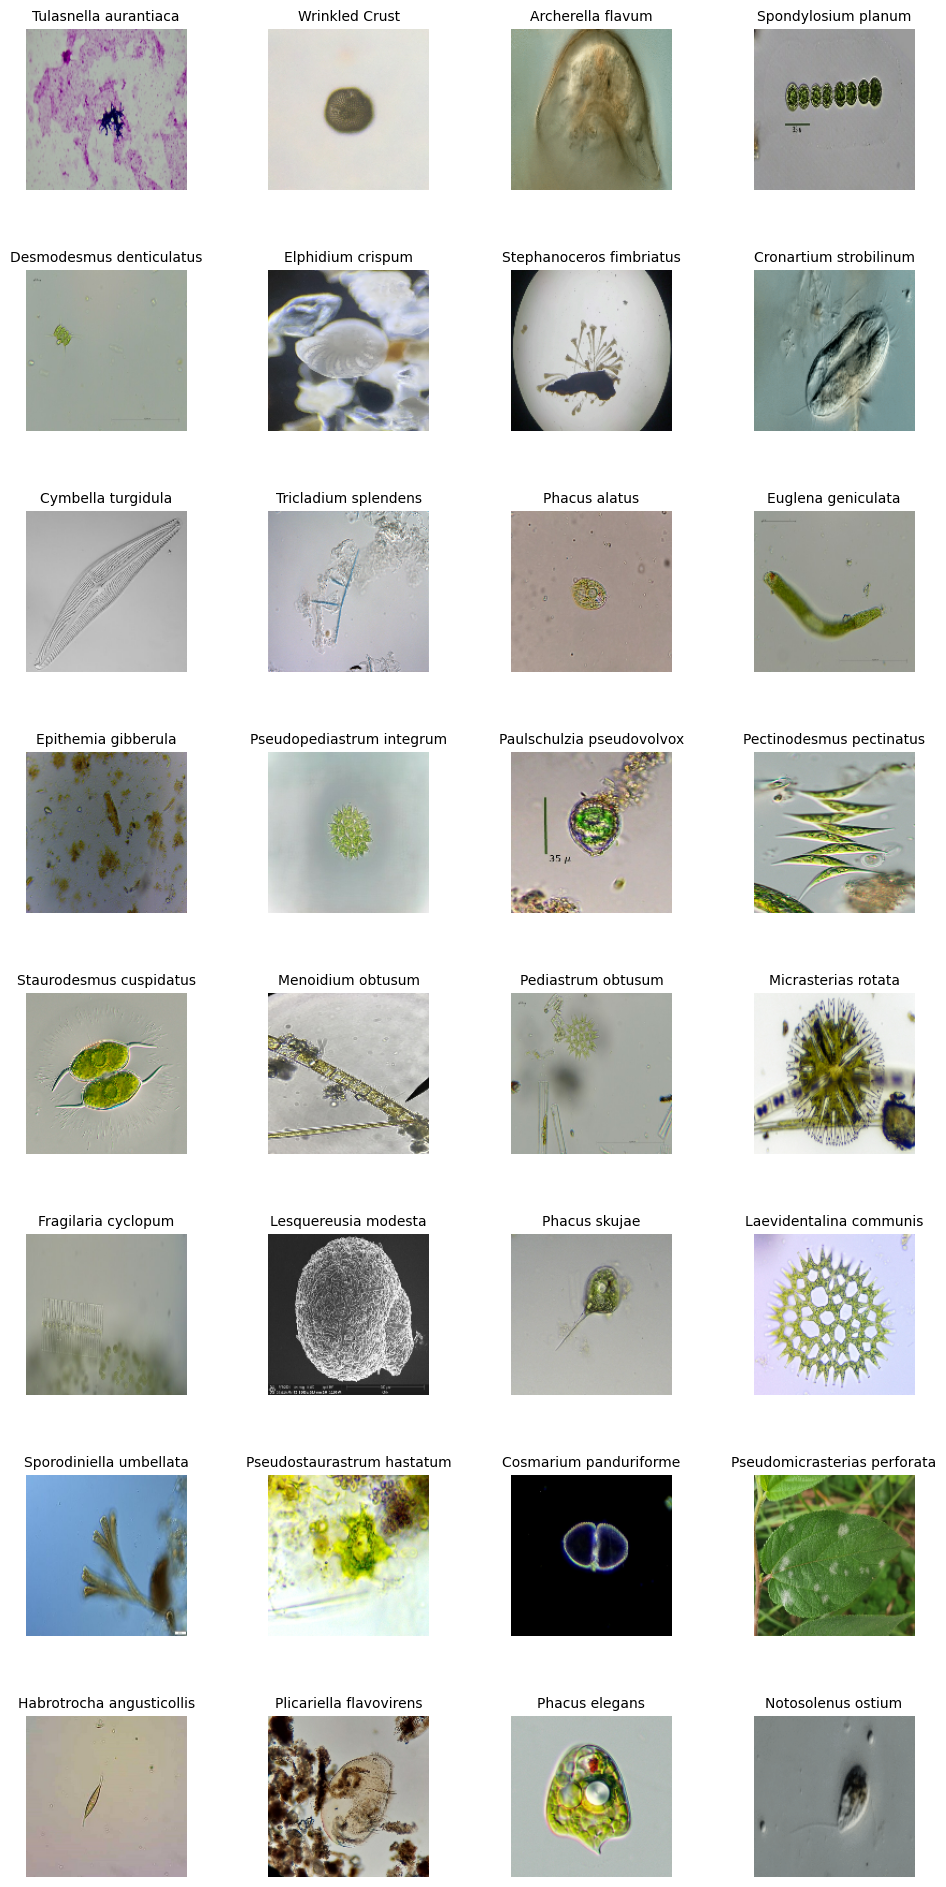

In [46]:
n_rows = 8
n_cols = 4
plt.figure(figsize=(n_cols * 3, n_rows * 3))

for images, labels in train_ds.take(1):
    for i in range(n_rows * n_cols):
        plt.subplot(n_rows, n_cols, i + 1)
        
        plt.imshow(images[i].numpy()) 
        
        plt.axis('off')
        
        label_idx = int(labels[i])
        plt.title(all_species[label_idx], fontsize=10)

plt.subplots_adjust(wspace=.2, hspace=.5)
plt.show()